In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold

In [3]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

In [4]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [6]:
y_pred = rfr.predict(X_test)
y_pred

array([34753.86, 11153.34, 37651.75, ..., 10924.25,  7310.49, 20362.26])

In [7]:
# Create a new DataFrame showing the samples indices next to the non-dummy columns.
# This will allow us to compare results side-by-side with these categorial columns.
samples_no_dummies = no_dummies.loc[X_test.index]

# Build a new DataFrame compiling the results of the Linear Regression for each sample.
# We can also load categorical columns into this DataFrame.
rfr_init_results = pd.DataFrame()
rfr_init_results['make_model'] = samples_no_dummies['make_model']
rfr_init_results['Actual Price'] = y_test
rfr_init_results['Predicted Price'] = np.round(y_pred).astype(int)
rfr_init_results['Error'] = rfr_init_results['Predicted Price'] - rfr_init_results['Actual Price']
rfr_init_results['Squared Error'] = rfr_init_results['Error'] ** 2
rfr_init_results['Absolute Error'] = rfr_init_results['Error'].abs()
rfr_init_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14845,Renault Espace,34985.0,34754,-231.0,53361.0,231.0
14120,Renault Clio,11280.0,11153,-127.0,16129.0,127.0
14860,Renault Espace,38875.0,37652,-1223.0,1495729.0,1223.0
884,Audi A1,14500.0,15492,992.0,984064.0,992.0
411,Audi A1,15900.0,16946,1046.0,1094116.0,1046.0
...,...,...,...,...,...,...
499,Audi A1,13700.0,13411,-289.0,83521.0,289.0
668,Audi A1,12451.0,12546,95.0,9025.0,95.0
8028,Opel Corsa,12990.0,10924,-2066.0,4268356.0,2066.0
8495,Opel Corsa,7650.0,7310,-340.0,115600.0,340.0


In [8]:
print(f"Mean squared error: {rfr_init_results['Squared Error'].mean()}")
print(f"Mean absolute error: {rfr_init_results['Absolute Error'].mean()}")
print(f"Median absolute error: {rfr_init_results['Absolute Error'].median()}")

Mean squared error: 2403832.873178808
Mean absolute error: 920.885761589404
Median absolute error: 524.5


In [9]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Median Absolute Error: {median_absolute_error(y_test, y_pred)}")

R2 Score: 0.9575224148675991
Mean Squared Error: 2403844.742603891
Mean Absolute Error: 920.8820879683966
Median Absolute Error: 524.3450000000003


In [10]:
rfr_init_results.nsmallest(10, 'Absolute Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
351,Audi A1,14990.0,14990,0.0,0.0,0.0
4800,Audi A3,27410.0,27410,0.0,0.0,0.0
13745,Renault Clio,9999.0,9999,0.0,0.0,0.0
339,Audi A1,14990.0,14990,0.0,0.0,0.0
99,Audi A1,18900.0,18900,0.0,0.0,0.0
290,Audi A1,15090.0,15090,0.0,0.0,0.0
12794,Renault Clio,8490.0,8490,0.0,0.0,0.0
286,Audi A1,15090.0,15090,0.0,0.0,0.0
9791,Opel Corsa,10979.0,10979,0.0,0.0,0.0
12462,Renault Clio,15485.0,15485,0.0,0.0,0.0


In [11]:
(rfr_init_results[rfr_init_results['Absolute Error'] == 0]).count()

make_model         82
Actual Price       82
Predicted Price    82
Error              82
Squared Error      82
Absolute Error     82
dtype: int64

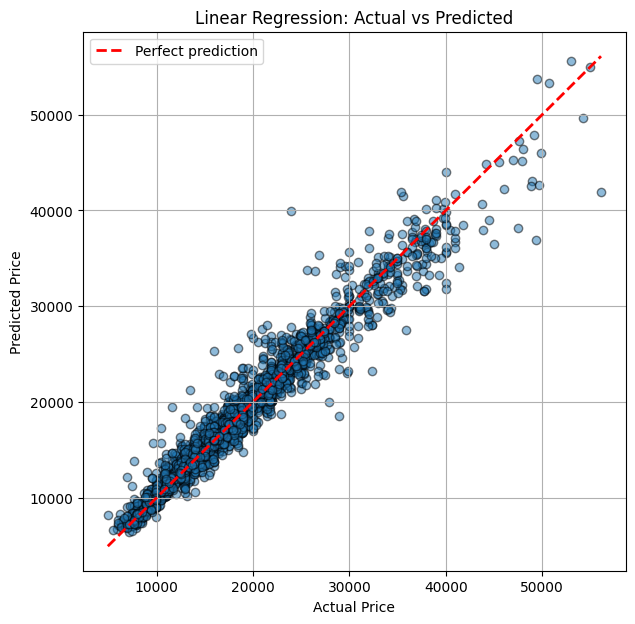

In [12]:
# Predictions on the test set
y_pred = rfr.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black', linewidths=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

# RFR with K Fold

In [13]:
# Define K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.95901787 0.95109791 0.9541112  0.95226104 0.95201512]
Mean R²: 0.9537006290907295
Standard deviation of R²: 0.002832986436964889


In [14]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfr, X, y, cv=kf)

# Build results dataframe
rfr_cv_results = pd.DataFrame()
rfr_cv_results['make_model'] = no_dummies['make_model']
rfr_cv_results['Actual Price'] = y
rfr_cv_results['Predicted Price'] = np.round(y_pred_all).astype(int)
rfr_cv_results['Error'] = rfr_cv_results['Predicted Price'] - rfr_cv_results['Actual Price']
rfr_cv_results['Squared Error'] = rfr_cv_results['Error'] ** 2
rfr_cv_results['Absolute Error'] = rfr_cv_results['Error'].abs()
rfr_cv_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
0,Audi A1,15770.0,16029,259.0,67081.0,259.0
1,Audi A1,14500.0,15019,519.0,269361.0,519.0
2,Audi A1,14640.0,14577,-63.0,3969.0,63.0
3,Audi A1,14500.0,14719,219.0,47961.0,219.0
4,Audi A1,16790.0,17207,417.0,173889.0,417.0
...,...,...,...,...,...,...
15095,Renault Espace,39950.0,40650,700.0,490000.0,700.0
15096,Renault Espace,39885.0,35880,-4005.0,16040025.0,4005.0
15097,Renault Espace,39875.0,38759,-1116.0,1245456.0,1116.0
15098,Renault Espace,39700.0,39143,-557.0,310249.0,557.0


In [15]:
(rfr_cv_results[rfr_cv_results['Absolute Error'] == 0])['Absolute Error'].count()

np.int64(478)

486 cars out of 15100 were predicted perfectly.

In [17]:
print(f"R2 Score: {r2_score(y, y_pred_all)}")
print(f"Mean Squared Error: {mean_squared_error(y, y_pred_all)}")
print(f"Mean Absolute Error: {mean_absolute_error(y, y_pred_all)}")
print(f"Median Absolute Error: {median_absolute_error(y, y_pred_all)}")

R2 Score: 0.9531075438076501
Mean Squared Error: 2584570.0551208737
Mean Absolute Error: 906.0162019922014
Median Absolute Error: 511.22000000000025


In [18]:
rfr_cv_results.to_csv('/Users/matthewcavanaugh/Desktop/GitHub/magnimind/Auto Scout Project/Model Results/RESULTS RFR no GS', index=False)

# RFR with GridSearchCV